<a href="https://colab.research.google.com/github/aishwarayshinde/Data-Analyst-Projects/blob/main/Customer_Segmentation_and_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective: Perform customer segmentation based on purchasing behavior and  predict future buying patterns.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# for predicting the buying patterns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [ ]:
# import file
df = pd.read_csv('Online Retail Dataset.csv')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010,3.39,17850,United Kingdom


In [ ]:
df.shape

(299583, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299583 entries, 0 to 299582
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    299583 non-null  int64  
 1   StockCode    299583 non-null  object 
 2   Description  299583 non-null  object 
 3   Quantity     299583 non-null  int64  
 4   InvoiceDate  299583 non-null  object 
 5   UnitPrice    299583 non-null  float64
 6   CustomerID   299583 non-null  int64  
 7   Country      299583 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 18.3+ MB


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y')

In [ ]:
df.isna()
df.dropna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
299578,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09,4.15,12680,France
299579,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680,France
299580,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680,France
299581,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680,France


# Feature Engineering

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'UnitPrice': 'sum',
    'Quantity': 'sum',
    'Country': 'first'
})
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency'}, inplace=True)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
rfm['Monetary'] = df.groupby('CustomerID')['TotalPrice'].sum()

rfm


,Recency,Frequency,UnitPrice,Quantity,Country,Monetary
CustomerID,,,,,,
12346,326,1,1.04,74215,United Kingdom,77183.60
12347,3,7,453.28,1578,Iceland,3764.48
12348,76,3,9.15,584,Finland,754.00
12349,19,1,298.63,496,Italy,1368.75
12350,311,1,22.75,150,Norway,255.30
...,...,...,...,...,...,...
18280,278,1,47.65,45,United Kingdom,180.60
18281,181,1,38.10,18,United Kingdom,65.70
18282,8,2,60.85,35,United Kingdom,152.45


Standardize and Score RFM Features

In [ ]:
# RFM scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

# Combine RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm

,Recency,Frequency,UnitPrice,Quantity,Country,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,,,
12346,326,1,1.04,74215,United Kingdom,77183.60,1,1,5,115
12347,3,7,453.28,1578,Iceland,3764.48,5,5,5,555
12348,76,3,9.15,584,Finland,754.00,2,3,3,233
12349,19,1,298.63,496,Italy,1368.75,4,1,4,414
12350,311,1,22.75,150,Norway,255.30,1,1,2,112
...,...,...,...,...,...,...,...,...,...,...
18280,278,1,47.65,45,United Kingdom,180.60,1,2,1,121
18281,181,1,38.10,18,United Kingdom,65.70,2,2,1,221
18282,8,2,60.85,35,United Kingdom,152.45,5,3,1,531


 Segment Customers

In [ ]:
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Big Spenders'
    elif row['R_Score'] >= 4:
        return 'Recent Customers'
    elif row['F_Score'] >= 4:
        return 'Frequent Buyers'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm

,Recency,Frequency,UnitPrice,Quantity,Country,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,,,,
12346,326,1,1.04,74215,United Kingdom,77183.60,1,1,5,115,Others
12347,3,7,453.28,1578,Iceland,3764.48,5,5,5,555,Champions
12348,76,3,9.15,584,Finland,754.00,2,3,3,233,Others
12349,19,1,298.63,496,Italy,1368.75,4,1,4,414,Big Spenders
12350,311,1,22.75,150,Norway,255.30,1,1,2,112,At Risk
...,...,...,...,...,...,...,...,...,...,...,...
18280,278,1,47.65,45,United Kingdom,180.60,1,2,1,121,At Risk
18281,181,1,38.10,18,United Kingdom,65.70,2,2,1,221,At Risk
18282,8,2,60.85,35,United Kingdom,152.45,5,3,1,531,Recent Customers


 Analyze Segment Distribution

In [ ]:
segment_counts = rfm['Segment'].value_counts()
segment_counts

,count
Segment,
Others,1140
At Risk,817
Loyal Customers,781
Frequent Buyers,602
Recent Customers,515
Champions,336
Big Spenders,107


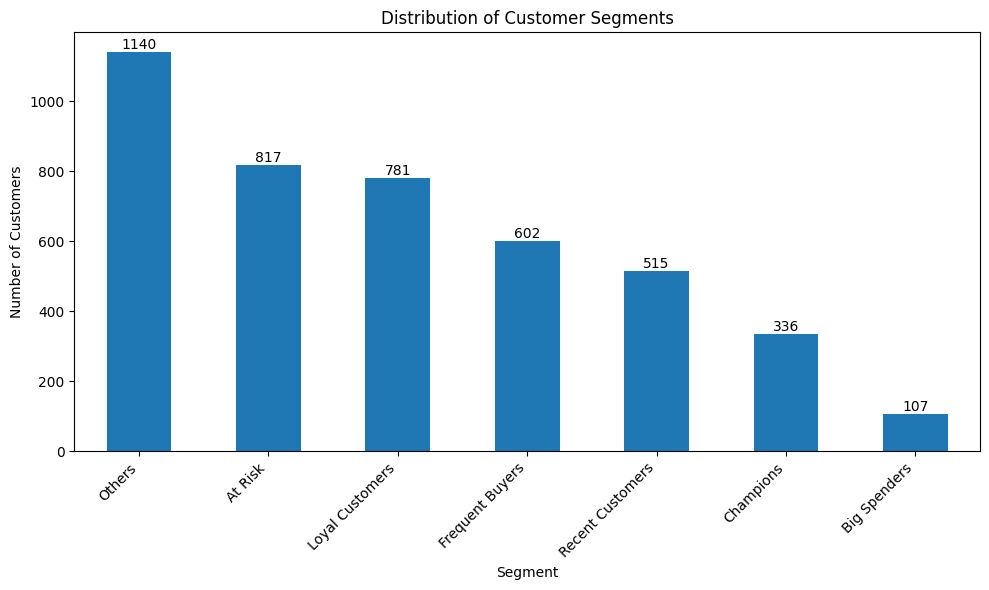

In [ ]:
# Bar chart for segment counts
plt.figure(figsize=(10, 6))
ax = segment_counts.plot(kind='bar')
plt.title('Distribution of Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')

# Add count labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

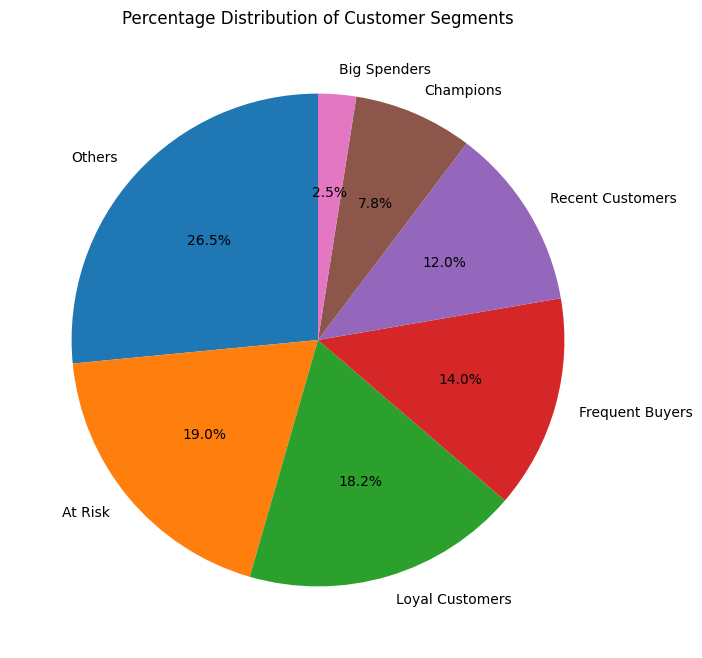

In [ ]:
# Pie chart showing percentage count
plt.figure(figsize=(8, 8))
segment_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Percentage Distribution of Customer Segments')
plt.ylabel('')
plt.show()

In [ ]:
segment_monetary = rfm.groupby('Segment')['Monetary'].mean()
segment_monetary

,Monetary
Segment,
At Risk,193.891591
Big Spenders,2942.778598
Champions,10168.787232
Frequent Buyers,1821.604817
Loyal Customers,2163.713713
Others,743.479035
Recent Customers,330.512641


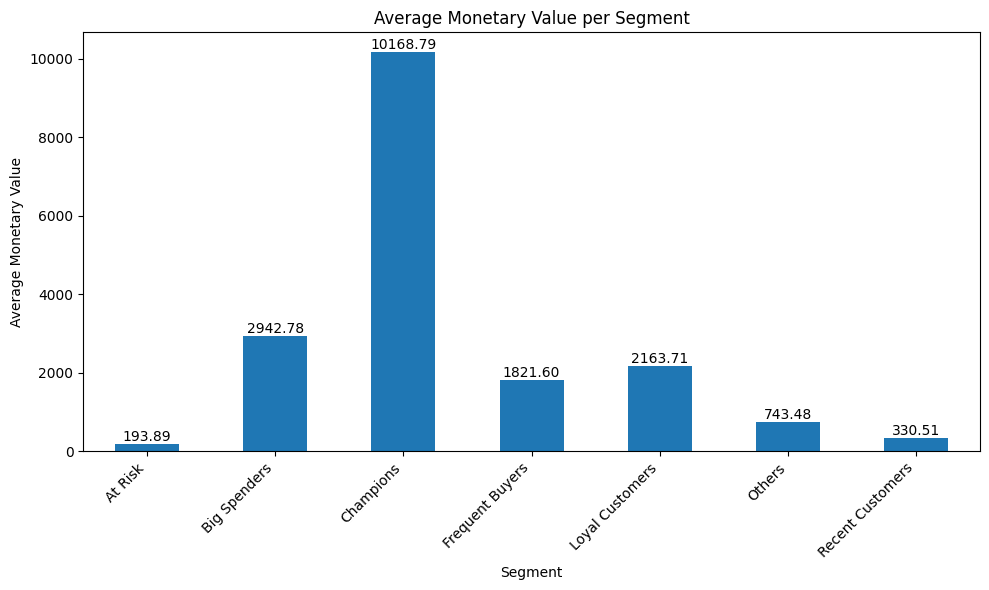

In [ ]:
# Bar chart for segment monetary
plt.figure(figsize=(10, 6))
ax = segment_monetary.plot(kind='bar')
plt.title('Average Monetary Value per Segment')
plt.xlabel('Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=45, ha='right')

# Add monetary labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

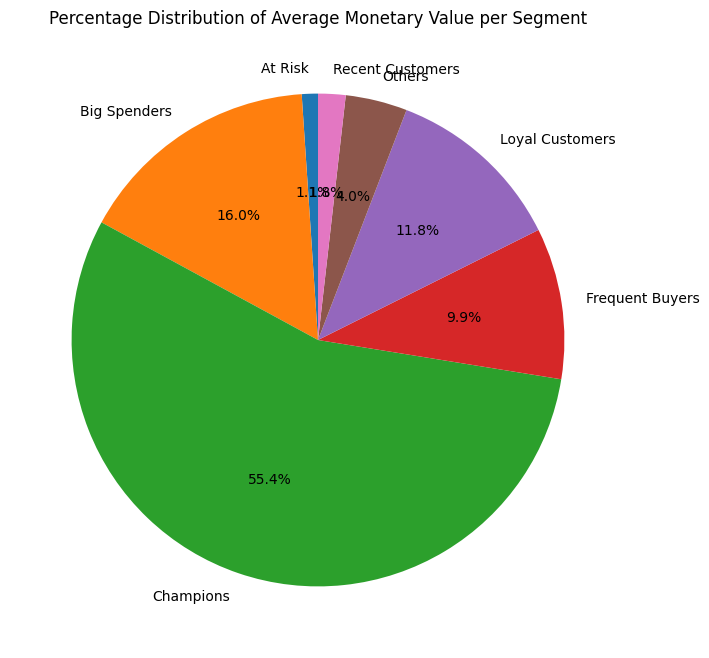

In [ ]:
# Pie chart for segment monetary percentage
plt.figure(figsize=(8, 8))
segment_monetary.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Percentage Distribution of Average Monetary Value per Segment')
plt.ylabel('')
plt.show()

# Customer Segmentation

**Objective:**
Group customers into meaningful clusters.

**Approach:**
Use K-Means Clustering on scaled RFM data.

**Elbow Plot :** Helps you see where adding more clusters stops significantly improving fit.

**Silhouette Score Plot :** Shows which k values give the most distinct and well-separated clusters.

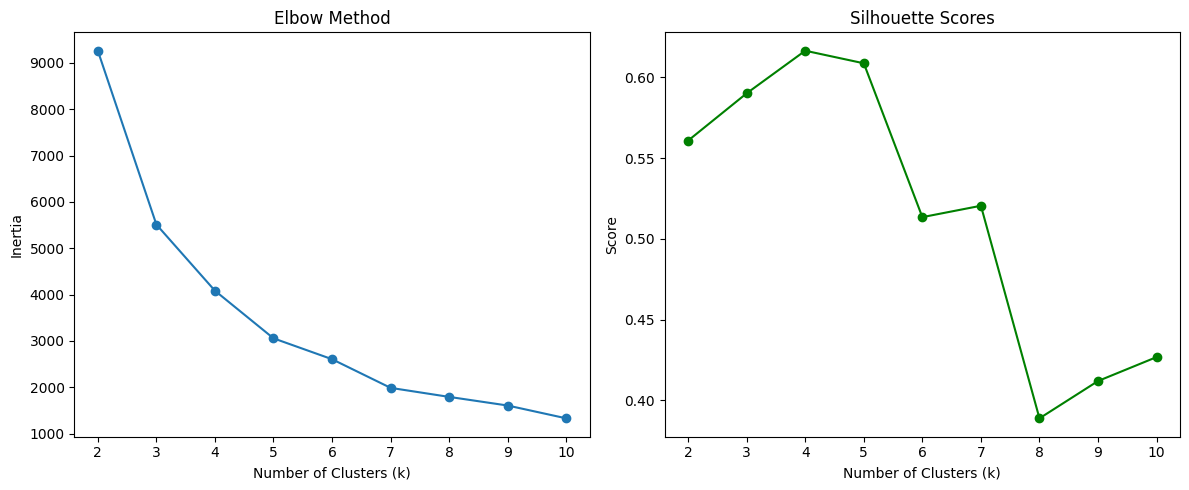

In [ ]:
# 1. Prepare data
scaler = StandardScaler()
X = rfm[['Recency', 'Frequency', 'Monetary']]
rfm_scaled = scaler.fit_transform(X)

# 2. Initialize lists
inertias = []
silhouette_scores = []
k_values = range(2, 11)  # Start from 2 because silhouette score is not defined for 1 cluster

# 3. Loop through k values
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

# 4. Plot Elbow method
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# 5. Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


**How to Decide :**

1.   Look for the "elbow" (point where line gets flattend)
     in the inertia plot.
2.   Choose a k where silhouette score is highest or near highest.

They often suggest the same k, but if they differ:



*   Prefer the one with higher silhouette if clarity of segmentation is         more     important.
*   Prefer lower k if business simplicity is preferred (e.g., 3 segments are easier to act on than 6).







So we will select k = 5 as it has highest silhouette score and it is close enough to elbow point. It gives richer segmentation without overcomplicating interpretation.

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm

,Recency,Frequency,UnitPrice,Quantity,Country,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
CustomerID,,,,,,,,,,,,
12346,326,1,1.04,74215,United Kingdom,77183.60,1,1,5,115,Others,3
12347,3,7,453.28,1578,Iceland,3764.48,5,5,5,555,Champions,1
12348,76,3,9.15,584,Finland,754.00,2,3,3,233,Others,1
12349,19,1,298.63,496,Italy,1368.75,4,1,4,414,Big Spenders,1
12350,311,1,22.75,150,Norway,255.30,1,1,2,112,At Risk,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18280,278,1,47.65,45,United Kingdom,180.60,1,2,1,121,At Risk,0
18281,181,1,38.10,18,United Kingdom,65.70,2,2,1,221,At Risk,0
18282,8,2,60.85,35,United Kingdom,152.45,5,3,1,531,Recent Customers,1


In [ ]:
rfm = rfm.reset_index()

rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).round(0)


,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,250.0,2.0,417.0,1058
1,45.0,3.0,1075.0,2943
2,7.0,83.0,55073.0,15
3,16.0,18.0,8648.0,278
4,3.0,44.0,214537.0,4


 Visualization: Cluster Characteristics

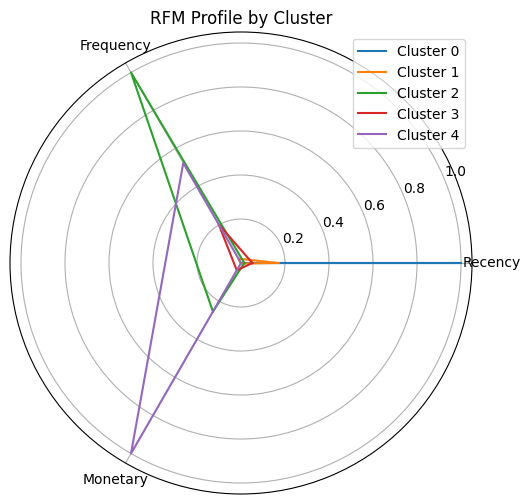

In [ ]:
# Normalize RFM features for radar chart
rfm_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
rfm_norm = (rfm_means - rfm_means.min()) / (rfm_means.max() - rfm_means.min())

# Radar chart setup
labels = ['Recency', 'Frequency', 'Monetary']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # complete the loop

plt.figure(figsize=(8,6))

for i, row in rfm_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, label=f'Cluster {i}')

plt.xticks(angles[:-1], labels)
plt.title('RFM Profile by Cluster')
plt.legend()
plt.show()


Cluster labelling

In [ ]:
r_avg = rfm['Recency'].mean()
f_avg = rfm['Frequency'].mean()
m_avg = rfm['Monetary'].mean()

In [ ]:
cluster_stats = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(0)


In [ ]:
def label_cluster(row):
    if row['Recency'] < r_avg and row['Frequency'] > f_avg and row['Monetary'] > m_avg:
        return 'Power Buyers'  # active, frequent, high-spending
    elif row['Recency'] < r_avg and row['Frequency'] < f_avg and row['Monetary'] < m_avg:
        return 'New & Cautious'  # recently joined, low frequency/value
    elif row['Recency'] > r_avg and row['Frequency'] > f_avg and row['Monetary'] > m_avg:
        return 'Loyal but Sleeping'  # used to be active, now less so
    elif row['Recency'] > r_avg and row['Frequency'] < f_avg and row['Monetary'] < m_avg:
        return 'Slipping Away'  # inactive, low engagement
    elif row['Recency'] > r_avg and row['Frequency'] < f_avg and row['Monetary'] > m_avg:
        return 'Premium Lost'  # inactive but high value
    else:
        return 'Mixed Behavior'


In [ ]:
cluster_stats['Segment'] = cluster_stats.apply(label_cluster, axis=1)

In [ ]:
rfm = rfm.merge(cluster_stats['Segment'], on='Cluster', how='left')
rfm

,CustomerID,Recency,Frequency,UnitPrice,Quantity,Country,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment_x,Cluster,Segment_y
0,12346,326,1,1.04,74215,United Kingdom,77183.60,1,1,5,115,Others,3,Power Buyers
1,12347,3,7,453.28,1578,Iceland,3764.48,5,5,5,555,Champions,1,New & Cautious
2,12348,76,3,9.15,584,Finland,754.00,2,3,3,233,Others,1,New & Cautious
3,12349,19,1,298.63,496,Italy,1368.75,4,1,4,414,Big Spenders,1,New & Cautious
4,12350,311,1,22.75,150,Norway,255.30,1,1,2,112,At Risk,0,Slipping Away
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4293,18280,278,1,47.65,45,United Kingdom,180.60,1,2,1,121,At Risk,0,Slipping Away
4294,18281,181,1,38.10,18,United Kingdom,65.70,2,2,1,221,At Risk,0,Slipping Away
4295,18282,8,2,60.85,35,United Kingdom,152.45,5,3,1,531,Recent Customers,1,New & Cautious
4296,18283,4,16,1016.66,863,United Kingdom,1708.90,5,5,4,554,Loyal Customers,3,Power Buyers


# Visualize Segment Distribution

A. Number of Customers in Each Segment

In [ ]:
rfm = rfm.drop(columns=['Segment'], errors='ignore')  # drop old one if it exists
rfm.rename(columns={'Segment_y': 'Segment'}, inplace=True)

/tmp/ipython-input-2911939866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


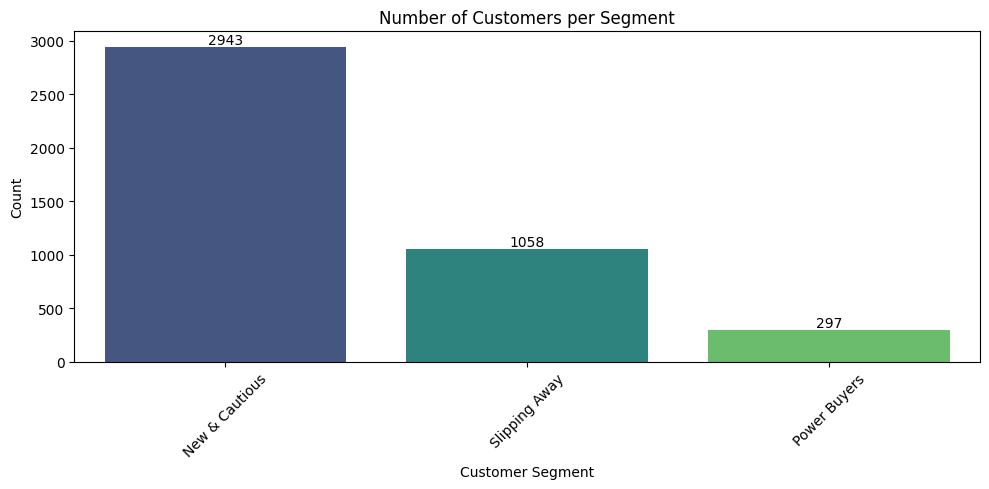

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Number of Customers per Segment')
plt.xticks(rotation=45)
plt.xlabel('Customer Segment')
plt.ylabel('Count')

# Add value labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

B. RFM Distribution by Segment (Boxplot)

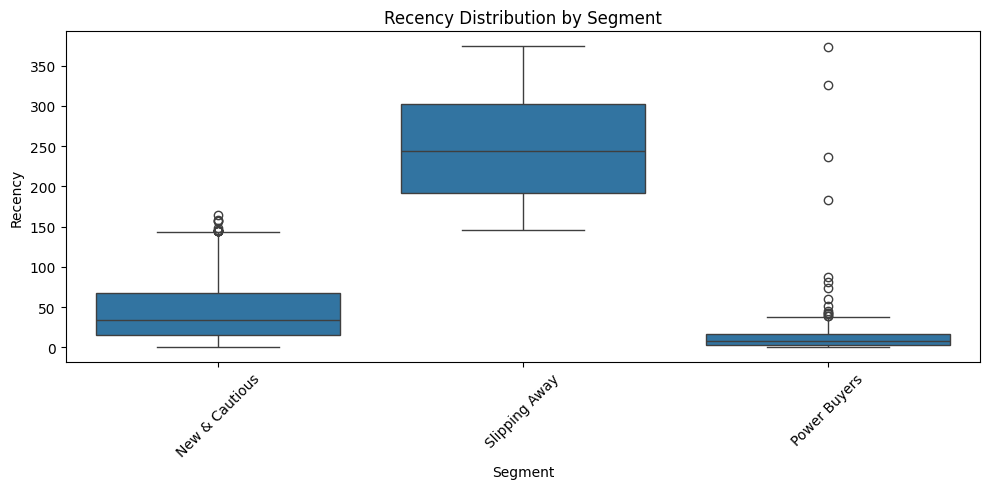

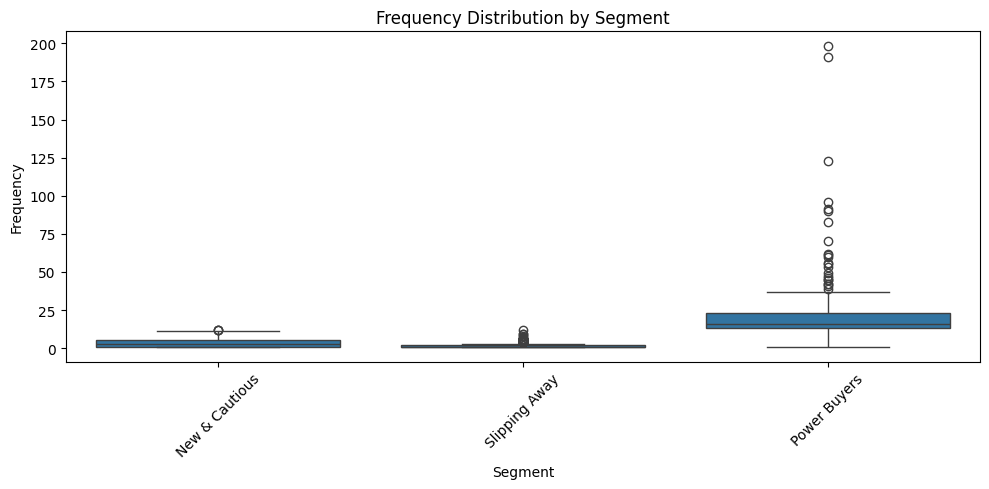

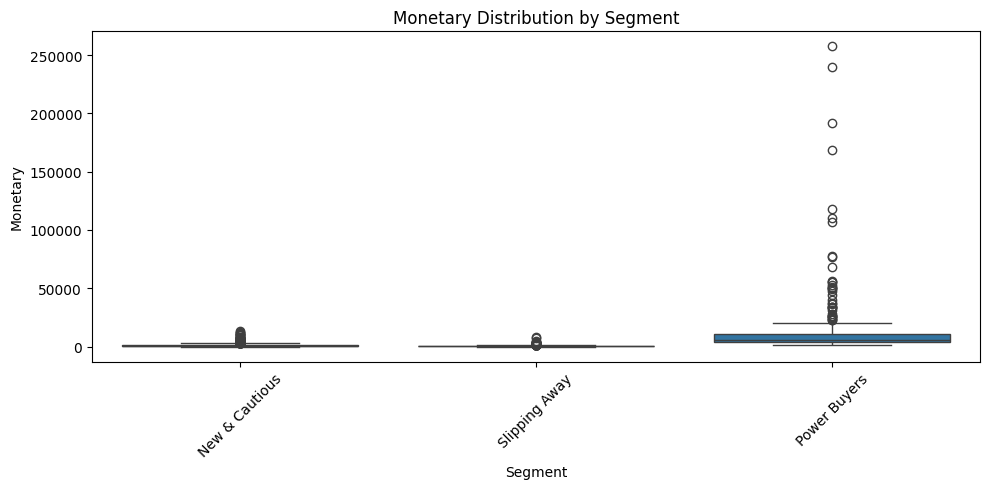

In [ ]:
for col in ['Recency', 'Frequency', 'Monetary']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=rfm, x='Segment', y=col, order=rfm['Segment'].value_counts().index)
    plt.title(f'{col} Distribution by Segment')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Predictive Modeling

 Objective:
Predict whether a customer will make a purchase in the next period.


A. Prepare Data

In [ ]:
# Encode segment labels
rfm_encoded = rfm.copy()
le = LabelEncoder() #Converts string labels like "Champions" to numbers like 0, 1, 2, etc., which are needed for most machine learning models.
rfm_encoded['SegmentEncoded'] = le.fit_transform(rfm_encoded['Segment'])

# Features & target
X = rfm_encoded[['Recency', 'Frequency', 'Monetary']]
y = rfm_encoded['SegmentEncoded']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


B. Train & Evaluate Model

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
                precision    recall  f1-score   support

New & Cautious       1.00      1.00      1.00       588
  Power Buyers       0.98      0.98      0.98        57
 Slipping Away       1.00      1.00      1.00       215

      accuracy                           1.00       860
     macro avg       0.99      0.99      0.99       860
  weighted avg       1.00      1.00      1.00       860



C. Predict for New Customer

In [ ]:
# not part of original code
#  this part is for testing pupose and values are also dummy

new_customer = pd.DataFrame({
    'Recency': [25],          # days since last purchase
    'Frequency': [3],         # number of purchases
    'Monetary': [450]         # total spent (e.g., ₹200)
})

predicted_segment = le.inverse_transform(model.predict(new_customer))
print("Predicted Segment:", predicted_segment[0])

Predicted Segment: New & Cautious


In [ ]:
test_cases = pd.DataFrame({
        'Recency': [5, 20, 60],
    'Frequency': [10, 3, 1],
    'Monetary': [500, 100, 30]
})

# Predict and decode
predicted = model.predict(test_cases)
test_cases['Predicted Segment'] = le.inverse_transform(predicted)
print(test_cases)


   Recency  Frequency  Monetary Predicted Segment
0        5         10       500    New & Cautious
1       20          3       100    New & Cautious
2       60          1        30    New & Cautious


**Confusion Matrix**

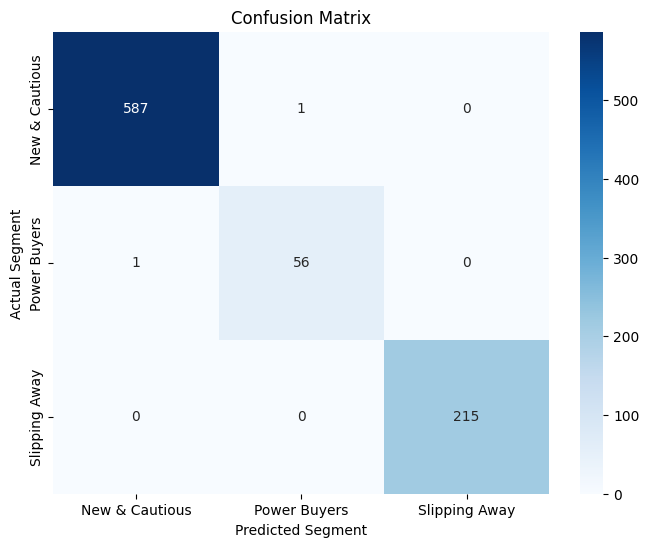

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = le.classes_  # e.g., ['At Risk', 'Champions', 'Loyal']

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Segment')
plt.ylabel('Actual Segment')
plt.title('Confusion Matrix')
plt.show()


**Feature Importance**

/tmp/ipython-input-361165094.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


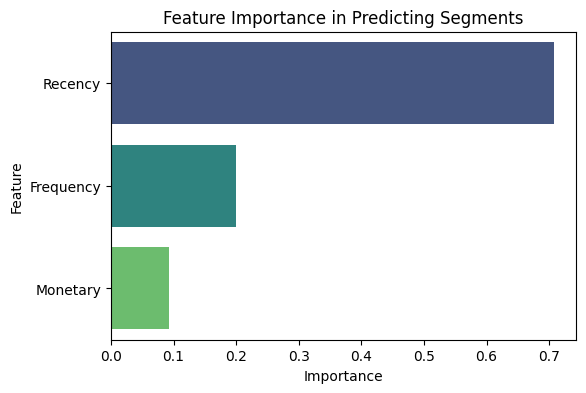

In [ ]:
# Get feature importances from Random Forest
importances = model.feature_importances_
features = X.columns

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance in Predicting Segments')
plt.show()
